# gnomAD-COSMIC pipeline — Dataset QC & Exploratory Analysis

Questo notebook esplora:
1. **Dataset overview** — numero varianti, cromosomi, distribuzione maf_bin
2. **AS_VQSLOD** — distribuzione e effetto del filtro su ΔE
3. **CpG statistics** — frazione CpG per dataset / regione / functional class
4. **ΔE overview** — distribuzione ΔE per regione, con e senza CpG
5. **COSMIC overview** — statistiche di base su cosmic_final.tsv

**Prerequisito**: avere già eseguito `scripts/01_build_parquet.py`
(il parquet deve esistere in `results/cache/gnomad_corrected.parquet`)

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Paths
PROJECT_DIR   = Path('..').resolve()
PARQUET_PATH  = PROJECT_DIR / 'results/cache/gnomad_corrected.parquet'
COSMIC_TSV    = Path('/leonardo_work/CNHPC_2116672/COSMIC_v103/processed/cosmic_final.tsv')
CHUNKSIZE     = 500_000
AUTOSOMES     = {str(i) for i in range(1, 23)}

print(f'Parquet exists: {PARQUET_PATH.exists()}')
print(f'COSMIC tsv   : {COSMIC_TSV.exists()}')

Parquet exists: True
COSMIC tsv   : True


---
## 1. Dataset Overview — gnomAD

In [2]:
df = pd.read_parquet(PARQUET_PATH)
df['CHROM'] = df['CHROM'].astype(str).str.replace('chr', '', regex=False)
df = df[df['CHROM'].isin(AUTOSOMES)].copy()

print(f'Righe totali     : {len(df):,}')
print(f'Cromosomi        : {sorted(df["CHROM"].unique(), key=int)}')
print(f'Colonne          : {list(df.columns)}')
print()
print('--- Region distribution ---')
print(df['region'].value_counts().to_string())
print()
print('--- Functional class (top 10) ---')
print(df['func_class'].value_counts().head(10).to_string())

Righe totali     : 62,160,496
Cromosomi        : ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22']
Colonne          : ['CHROM', 'E_ref', 'E_mut', 'delta_E', 'is_cpg', 'func_class', 'region', 'maf_bin', 'AS_VQSLOD', 'AF']

--- Region distribution ---
region
exon          26944994
extragenic    20534210
intron        14681292

--- Functional class (top 10) ---
func_class
extragenic    20495807
utr           14466448
intron        14344560
missense       8132972
synonymous     4069989
splice          336732
stop            275585
intergenic       31497
regulatory        6904
noncoding            2


--- maf_bin distribution ---
maf_bin
ultra_rare     30666071
very_rare      22426195
rare            3766103
singleton       2830914
low_freq        1374150
common_5         484235
common_50        326176
very_common      143566
common_10        134888
missing            8198


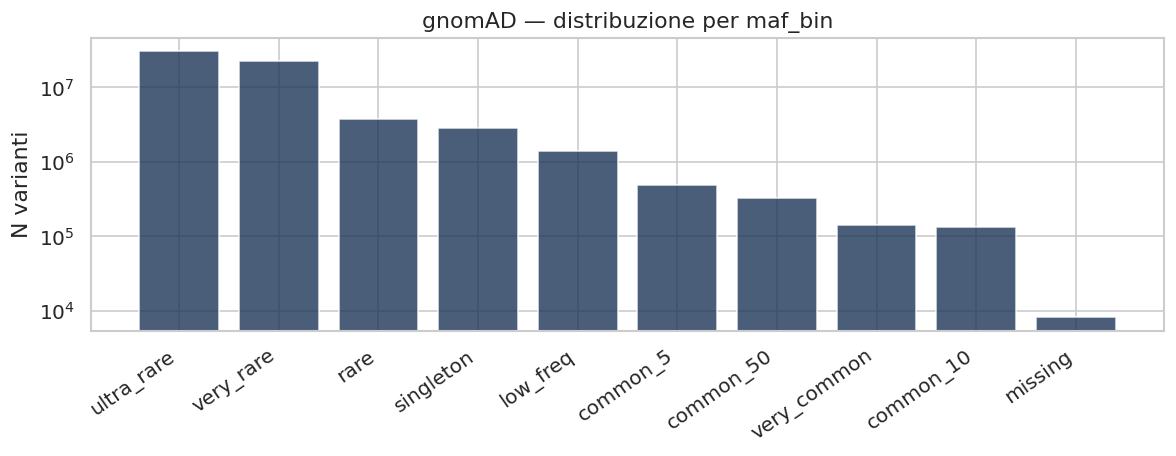

In [3]:
if 'maf_bin' in df.columns:
    print('--- maf_bin distribution ---')
    mb = df['maf_bin'].value_counts()
    print(mb.to_string())

    fig, ax = plt.subplots(figsize=(10, 4))
    mb_sorted = df['maf_bin'].value_counts().sort_index()
    ax.bar(range(len(mb)), mb.values, color='#1d3557', alpha=0.8)
    ax.set_xticks(range(len(mb)))
    ax.set_xticklabels(mb.index, rotation=35, ha='right')
    ax.set_ylabel('N varianti')
    ax.set_title('gnomAD — distribuzione per maf_bin')
    ax.set_yscale('log')
    plt.tight_layout()
    plt.show()

In [4]:
chrom_counts = df.groupby('CHROM').size().reset_index(name='n_variants')
chrom_counts['chrom_int'] = chrom_counts['CHROM'].astype(int)
chrom_counts = chrom_counts.sort_values('chrom_int')

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(chrom_counts)), chrom_counts['n_variants'],
       color='#1d3557', alpha=0.8, edgecolor='white', lw=0.5)
ax.set_xticks(range(len(chrom_counts)))
ax.set_xticklabels([f'chr{c}' for c in chrom_counts['CHROM']], rotation=45, ha='right')
ax.set_ylabel('N varianti')
ax.set_title('gnomAD — varianti per cromosoma')
plt.tight_layout()
plt.show()

: 

---
## 2. AS_VQSLOD — Distribuzione e Effetto sul Filtro

In [ ]:
if 'AS_VQSLOD' not in df.columns:
    print('AS_VQSLOD non disponibile nel parquet')
else:
    vq = df['AS_VQSLOD'].dropna()
    print(f'AS_VQSLOD — {len(vq):,} valori non-NA  ({vq.isna().sum():,} NA)')
    print(vq.describe().to_string())

    thresholds = [0, 1, 2, 5, 10, 20]
    for thr in thresholds:
        n = (vq >= thr).sum()
        pct = n / len(vq) * 100
        print(f'  VQSLOD >= {thr:2d}: {n:>10,}  ({pct:.1f}%)')

In [ ]:
if 'AS_VQSLOD' in df.columns:
    vq = df['AS_VQSLOD'].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Distribuzione completa
    axes[0].hist(vq.clip(-30, 50), bins=200, color='#1d3557', alpha=0.7, density=True)
    for thr, c in [(0, '#e63946'), (10, '#f4a261'), (20, '#2a9d8f')]:
        axes[0].axvline(thr, color=c, lw=1.5, ls='--', label=f'VQSLOD={thr}')
    axes[0].set_xlabel('AS_VQSLOD')
    axes[0].set_ylabel('Density')
    axes[0].set_title('AS_VQSLOD distribution (clipped -30..50)')
    axes[0].legend(fontsize=9)

    # Effetto del filtro su mean(delta_E) per regione
    rows = []
    for thr in [None, 0, 2, 5, 10, 20]:
        sub = df if thr is None else df[df['AS_VQSLOD'] >= thr]
        for reg in ['exon', 'intron', 'extragenic']:
            vals = sub[sub['region'] == reg]['delta_E'].dropna()
            rows.append({'threshold': 'all' if thr is None else f'>={thr}',
                         'region': reg, 'mean_dE': vals.mean(), 'n': len(vals)})
    vq_effect = pd.DataFrame(rows)

    for reg, col in [('exon','#e63946'), ('intron','#1d3557'), ('extragenic','#2a9d8f')]:
        sub = vq_effect[vq_effect['region'] == reg]
        axes[1].plot(sub['threshold'], sub['mean_dE'], 'o-',
                     color=col, label=reg, lw=2, ms=7)
    axes[1].set_xlabel('VQSLOD threshold')
    axes[1].set_ylabel('mean ΔE')
    axes[1].set_title('Effetto filtro VQSLOD su mean(ΔE) per regione')
    axes[1].legend()
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()
    display(vq_effect.pivot(index='threshold', columns='region', values='mean_dE').round(4))

---
## 3. CpG Statistics

In [ ]:
print('=== gnomAD CpG fraction ===')
print(f'  Overall           : {df["is_cpg"].mean():.4f}')
print()
print('  Per region:')
print(df.groupby('region')['is_cpg'].mean().round(4).to_string())
print()
print('  Per func_class (top 10 by n):')
fc_cpg = df.groupby('func_class').agg(
    n=('is_cpg', 'count'),
    cpg_frac=('is_cpg', 'mean')
).sort_values('n', ascending=False).head(10)
print(fc_cpg.round(4).to_string())

In [ ]:
# CpG fraction COSMIC (usa cosmic_final.tsv)
if COSMIC_TSV.exists():
    co_records = []
    for chunk in pd.read_csv(
        COSMIC_TSV, sep='\t', chunksize=CHUNKSIZE,
        usecols=['chrom', 'is_coding', 'is_cpg'],
        dtype={'chrom': str, 'is_coding': str, 'is_cpg': 'Int64'},
    ):
        chunk['chrom']  = chunk['chrom'].str.replace('chr', '', regex=False)
        chunk['is_cpg'] = pd.to_numeric(chunk['is_cpg'], errors='coerce').fillna(0).astype(int)
        co_records.append(chunk[chunk['chrom'].isin(AUTOSOMES)][['is_coding', 'is_cpg']])
    co_df = pd.concat(co_records, ignore_index=True)

    print('=== COSMIC CpG fraction ===')
    print(f'  Overall           : {co_df["is_cpg"].mean():.4f}')
    print('  Per is_coding:')
    print(co_df.groupby('is_coding')['is_cpg'].mean().round(4).to_string())
    print()

    # Bar chart comparison
    compare = pd.DataFrame({
        'gnomAD': [df['is_cpg'].mean(),
                   df[df['region']=='exon']['is_cpg'].mean(),
                   df[df['region']=='intron']['is_cpg'].mean(),
                   df[df['region']=='extragenic']['is_cpg'].mean()],
        'COSMIC': [co_df['is_cpg'].mean(),
                   co_df[co_df['is_coding']=='coding']['is_cpg'].mean(),
                   np.nan,
                   co_df[co_df['is_coding']=='non_coding']['is_cpg'].mean()],
    }, index=['overall', 'exon/coding', 'intron', 'extragenic/noncoding'])

    compare.plot(kind='bar', figsize=(8, 4), color=['#1d3557', '#e63946'],
                 alpha=0.8, edgecolor='black', lw=0.8)
    plt.ylabel('CpG fraction')
    plt.title('CpG fraction: gnomAD vs COSMIC')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()
    display(compare.round(4))

---
## 4. ΔE Distribution Overview

In [ ]:
print('=== gnomAD mean(ΔE) per regione e CpG class ===')
tbl = df.groupby(['region', 'is_cpg'])['delta_E'].agg(['mean', 'std', 'count']).round(4)
tbl.columns = ['mean_dE', 'std_dE', 'n']
display(tbl)

# KDE ΔE per regione
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, reg in zip(axes, ['exon', 'intron', 'extragenic']):
    for cpg, color, lbl in [(0, '#1d3557', 'non-CpG'), (1, '#e63946', 'CpG')]:
        vals = df[(df['region'] == reg) & (df['is_cpg'] == cpg)]['delta_E'].dropna()
        if len(vals) > 1000:
            vals = vals.sample(min(100_000, len(vals)), random_state=42)
        if len(vals) > 10:
            sns.kdeplot(vals, ax=ax, fill=True, alpha=0.3, lw=2,
                        color=color, bw_adjust=0.5,
                        label=f'{lbl}  μ={vals.mean():+.3f}')
            ax.axvline(vals.mean(), color=color, ls=':', lw=1.5)
    ax.axvline(0, color='gray', ls='--', lw=1, alpha=0.5)
    ax.set_title(reg.upper())
    ax.set_xlabel('ΔE  (E_ref − E_mut)')
    ax.legend(fontsize=8)
fig.suptitle('gnomAD ΔE distributions by region and CpG class', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ΔE vs MAF bin
if 'maf_bin' in df.columns:
    maf_order = ['ultra_rare', 'very_rare', 'rare', 'low_freq',
                 'common_5', 'common_10', 'common_50', 'very_common']
    present   = [b for b in maf_order if b in df['maf_bin'].values]

    maf_stats = []
    for mb in present:
        sub = df[df['maf_bin'] == mb]
        for reg in ['exon', 'intron', 'extragenic']:
            vals = sub[sub['region'] == reg]['delta_E'].dropna()
            maf_stats.append({'maf_bin': mb, 'region': reg,
                               'mean_dE': vals.mean(), 'n': len(vals)})
    maf_df = pd.DataFrame(maf_stats)

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(present))
    w = 0.25
    for i, (reg, col) in enumerate(zip(
        ['exon', 'intron', 'extragenic'],
        ['#e63946', '#1d3557', '#2a9d8f']
    )):
        sub = maf_df[maf_df['region'] == reg].set_index('maf_bin').reindex(present)
        ax.bar(x + i * w - w, sub['mean_dE'].fillna(0), w,
               color=col, alpha=0.8, label=reg, edgecolor='black', lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(present, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('mean ΔE')
    ax.set_title('gnomAD — mean ΔE per maf_bin e regione')
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.legend()
    plt.tight_layout()
    plt.show()
    display(maf_df.pivot(index='maf_bin', columns='region', values='mean_dE').round(4))

---
## 5. COSMIC Dataset Overview

In [ ]:
if COSMIC_TSV.exists():
    records_co = []
    for chunk in pd.read_csv(
        COSMIC_TSV, sep='\t', chunksize=CHUNKSIZE,
        usecols=['chrom', 'E_wt7', 'E_mut7', 'is_coding', 'is_cpg', 'in_cgc'],
        dtype={'chrom': str, 'is_coding': str, 'in_cgc': 'Int64', 'is_cpg': 'Int64'},
    ):
        chunk['chrom']  = chunk['chrom'].str.replace('chr', '', regex=False)
        chunk['is_cpg'] = pd.to_numeric(chunk['is_cpg'], errors='coerce').fillna(0).astype(int)
        chunk['in_cgc'] = pd.to_numeric(chunk['in_cgc'], errors='coerce').fillna(0).astype(int)
        chunk = chunk[chunk['chrom'].isin(AUTOSOMES)].copy()
        chunk['dE'] = (
            pd.to_numeric(chunk['E_wt7'],  errors='coerce')
            - pd.to_numeric(chunk['E_mut7'], errors='coerce')
        )
        records_co.append(chunk.dropna(subset=['dE']))
    co_full = pd.concat(records_co, ignore_index=True)

    print(f'Righe totali COSMIC    : {len(co_full):,}')
    print(f'Cromosomi              : {sorted(co_full["chrom"].unique(), key=int)}')
    print(f'mean(dE)               : {co_full["dE"].mean():+.4f}')
    print(f'CpG fraction           : {co_full["is_cpg"].mean():.4f}')
    print()
    print('is_coding distribution:')
    print(co_full['is_coding'].value_counts().to_string())
    print()
    print('in_cgc distribution (driver gene flag):')
    print(co_full[co_full['is_coding']=='coding']['in_cgc'].value_counts().to_string())

In [ ]:
if 'co_full' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # ΔE distribution COSMIC vs gnomAD exon
    ax = axes[0]
    for vals, color, lbl in [
        (df[df['region']=='exon']['delta_E'].sample(min(200_000, len(df)), random_state=0),
         '#1d3557', 'gnomAD exon'),
        (co_full[co_full['is_coding']=='coding']['dE'],
         '#e63946', 'COSMIC coding'),
    ]:
        v = vals.dropna().values
        if len(v) > 50_000:
            v = np.random.choice(v, 50_000, replace=False)
        sns.kdeplot(v, ax=ax, fill=True, alpha=0.3, lw=2, color=color,
                    bw_adjust=0.5, label=f'{lbl}  μ={v.mean():+.3f}')
        ax.axvline(v.mean(), color=color, ls=':', lw=2)
    ax.axvline(0, color='gray', ls='--', lw=1, alpha=0.5)
    ax.set_xlabel('ΔE  (E_ref − E_mut)')
    ax.set_ylabel('Density')
    ax.set_title('ΔE globale: COSMIC coding vs gnomAD exon')
    ax.legend(fontsize=9)

    # Per-chrom mean ΔE
    ax = axes[1]
    gn_chrom = df[df['region']=='exon'].groupby('CHROM')['delta_E'].mean().reset_index()
    gn_chrom['chrom_int'] = gn_chrom['CHROM'].astype(int)
    gn_chrom = gn_chrom.sort_values('chrom_int')

    co_chrom = co_full[co_full['is_coding']=='coding'].groupby('chrom')['dE'].mean().reset_index()
    co_chrom['chrom_int'] = co_chrom['chrom'].astype(int)
    co_chrom = co_chrom.sort_values('chrom_int')

    x = np.arange(22)
    ax.plot(x, gn_chrom['delta_E'].values, 'o-', color='#1d3557', lw=1.5, ms=5, label='gnomAD exon')
    ax.plot(x, co_chrom['dE'].values,      's-', color='#e63946', lw=1.5, ms=5, label='COSMIC coding')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{c}' for c in gn_chrom['CHROM']], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('mean ΔE')
    ax.set_title('Per-chromosome mean ΔE (exon/coding)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## 6. Riepilogo Statistiche

In [ ]:
summary_rows = []
for reg in ['exon', 'intron', 'extragenic']:
    for cpg_val, cpg_lbl in [(0, 'non-CpG'), (1, 'CpG')]:
        sub = df[(df['region']==reg) & (df['is_cpg']==cpg_val)]
        summary_rows.append({
            'dataset': 'gnomAD',
            'region': reg,
            'cpg_class': cpg_lbl,
            'n_variants': len(sub),
            'mean_dE': round(sub['delta_E'].mean(), 5),
            'std_dE':  round(sub['delta_E'].std(),  5),
        })

if 'co_full' in dir():
    for is_coding, reg in [('coding', 'exon'), ('non_coding', 'extragenic')]:
        for cpg_val, cpg_lbl in [(0, 'non-CpG'), (1, 'CpG')]:
            sub = co_full[(co_full['is_coding']==is_coding) & (co_full['is_cpg']==cpg_val)]
            summary_rows.append({
                'dataset': 'COSMIC',
                'region': reg,
                'cpg_class': cpg_lbl,
                'n_variants': len(sub),
                'mean_dE': round(sub['dE'].mean(), 5),
                'std_dE':  round(sub['dE'].std(),  5),
            })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_df.to_csv(PROJECT_DIR / 'results' / 'dataset_qc_summary.csv', index=False)
print('Salvato: results/dataset_qc_summary.csv')